# Brazilian E-Commerce Public Dataset Analysis by Olist

## Project Overview
This project performs an exploratory data analysis (EDA) on the Brazilian E-Commerce Public Dataset provided by Olist. The dataset contains approximately 100,000 orders from 2016 to 2018 across multiple marketplaces in Brazil.

## Data Source
The dataset is publicly available on Kaggle:

[https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

## Author
Haseeb Ahmad
135456

Course: Computation for Economics and Business
Master's Degree

## Key Questions to Answer
1. Which product categories generate the highest total revenue?
2. How does the difference between actual and estimated delivery times impact customer review scores?
3. What is the geographic distribution of orders across Brazilian states, and how does the average freight cost vary by state?
4. Are there identifiable seasonal trends or peak times (e.g., day of the week, month) for purchasing activity?
5. What is the relationship between the chosen payment method (e.g., credit card, voucher) and the average order value?

## Notebook Structure
1. Data Loading and Initial Exploration
2. Data Cleaning and Preparation
3. Merging Datasets
4. Answering Each Research Question
5. Conclusions

# Import necessary libraries

In [41]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for better-looking plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Display settings - show all columns when viewing dataframes
pd.set_option('display.max_columns', None)

# Print confirmation
print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.4.0


# Load all datasets

In [24]:
# Load all datasets
customers = pd.read_csv('olist_customers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')

# Print confirmation with shapes
print("Datasets loaded successfully!")
print("\n--- Dataset Shapes ---")
print(f"Customers: {customers.shape}")
print(f"Geolocation: {geolocation.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Order Payments: {order_payments.shape}")
print(f"Order Reviews: {order_reviews.shape}")
print(f"Orders: {orders.shape}")
print(f"Products: {products.shape}")
print(f"Sellers: {sellers.shape}")
print(f"Category Translation: {category_translation.shape}")

Datasets loaded successfully!

--- Dataset Shapes ---
Customers: (99441, 5)
Geolocation: (1000163, 5)
Order Items: (112650, 7)
Order Payments: (103886, 5)
Order Reviews: (99224, 7)
Orders: (99441, 8)
Products: (32951, 9)
Sellers: (3095, 4)
Category Translation: (71, 2)


In [25]:
# Display first 3 rows of each dataset to understand structure
print("=" * 50)
print("CUSTOMERS DATASET PREVIEW")
print("=" * 50)
display(customers.head(3))

print("\n" + "=" * 50)
print("ORDERS DATASET PREVIEW")
print("=" * 50)
display(orders.head(3))

print("\n" + "=" * 50)
print("ORDER ITEMS DATASET PREVIEW")
print("=" * 50)
display(order_items.head(3))

print("\n" + "=" * 50)
print("PRODUCTS DATASET PREVIEW")
print("=" * 50)
display(products.head(3))

print("\n" + "=" * 50)
print("CATEGORY TRANSLATION PREVIEW")
print("=" * 50)
display(category_translation.head(3))

print("\n" + "=" * 50)
print("ORDER PAYMENTS DATASET PREVIEW")
print("=" * 50)
display(order_payments.head(3))

print("\n" + "=" * 50)
print("ORDER REVIEWS DATASET PREVIEW")
print("=" * 50)
display(order_reviews.head(3))

CUSTOMERS DATASET PREVIEW


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



ORDERS DATASET PREVIEW


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



ORDER ITEMS DATASET PREVIEW


...

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto



ORDER PAYMENTS DATASET PREVIEW


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71



ORDER REVIEWS DATASET PREVIEW


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


Function for displaying dataset info

In [26]:
# Function to display dataset info
def dataset_info(df, name):
    print(f"\n{'='*50}")
    print(f"INFORMATION ABOUT: {name}")
    print(f"{'='*50}")
    print(f"Shape: {df.shape}")
    print(f"\nData Types:")
    print(df.dtypes)
    print(f"\nMissing Values:")
    missing = df.isnull().sum()
    print(missing[missing > 0] if any(missing > 0) else "No missing values")
    print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Get information for each dataset
dataset_info(customers, "CUSTOMERS")
dataset_info(orders, "ORDERS")
dataset_info(order_items, "ORDER ITEMS")
dataset_info(products, "PRODUCTS")
dataset_info(category_translation, "CATEGORY TRANSLATION")
dataset_info(order_payments, "ORDER PAYMENTS")
dataset_info(order_reviews, "ORDER REVIEWS")


INFORMATION ABOUT: CUSTOMERS
Shape: (99441, 5)

Data Types:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Missing Values:
No missing values

Memory Usage: 26.59 MB

INFORMATION ABOUT: ORDERS
Shape: (99441, 8)

Data Types:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Missing Values:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Memory Usage: 52.94 MB

INFORMATION ABOUT: ORDER ITEMS
Shape: (112650, 7)

Data Types:
order_id                object
order_item_id            int64
produ

Handle Missing Values in Products Dataset

In [27]:
# Check how many products are missing category names
missing_categories = products['product_category_name'].isnull().sum()
total_products = len(products)

print(f"Products without category: {missing_categories} out of {total_products}")
print(f"Percentage: {missing_categories/total_products*100:.2f}%")

# Let's see what these missing category rows look like
print("\nSample of products with missing category:")
display(products[products['product_category_name'].isnull()].head(3))
#Drop them (since 1.85% is relatively small)
products_clean = products.dropna(subset=['product_category_name'])
print(f"\nAfter dropping missing categories: {len(products_clean)} products remaining")

Products without category: 610 out of 32951
Percentage: 1.85%

Sample of products with missing category:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0



After dropping missing categories: 32341 products remaining


Convert Date Columns to Datetime

In [28]:
# List of date columns in orders dataset
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

# Convert each date column to datetime
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], format='mixed')
    print(f"Converted {col} to datetime")

# Also convert dates in reviews dataset
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])

# Convert shipping limit date in order_items
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

print("\nAll date columns converted successfully!")
print("\nOrders date range:")
print(f"Earliest order: {orders['order_purchase_timestamp'].min()}")
print(f"Latest order: {orders['order_purchase_timestamp'].max()}")

Converted order_purchase_timestamp to datetime
Converted order_approved_at to datetime
Converted order_delivered_carrier_date to datetime
Converted order_delivered_customer_date to datetime
Converted order_estimated_delivery_date to datetime

All date columns converted successfully!

Orders date range:
Earliest order: 2016-09-04 21:15:19
Latest order: 2018-10-17 17:30:18


Merge Category Translation with Products

In [29]:
# Merge products with category translation to get English names
products_with_categories = products_clean.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

# Check the merge result
print("Products with English category names:")
print(f"Shape: {products_with_categories.shape}")
print(f"\nSample of merged data:")
display(products_with_categories[['product_id', 'product_category_name', 'product_category_name_english']].head(10))

# Verify no missing English names after merge
missing_english = products_with_categories['product_category_name_english'].isnull().sum()
print(f"\nProducts missing English translation: {missing_english}")

# Instead of using inplace=True, we create a new column or reassign
products_with_categories['product_category_name_english'] = products_with_categories['product_category_name_english'].fillna(
    products_with_categories['product_category_name']
)

# Verify the fix worked
missing_after_fill = products_with_categories['product_category_name_english'].isnull().sum()
print(f"Products still missing after fill: {missing_after_fill}")

# Show a sample of the filled values (if any were filled)
if missing_english > 0:
    print("\nSample of products that had missing English names (now filled with Portuguese):")
    filled_sample = products_with_categories[products_with_categories['product_category_name_english'] == products_with_categories['product_category_name']].head(5)
    display(filled_sample[['product_id', 'product_category_name', 'product_category_name_english']])

Products with English category names:
Shape: (32341, 10)

Sample of merged data:


,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,musical_instruments
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,cool_stuff
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,furniture_decor
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,home_appliances
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,toys



Products missing English translation: 13
Products still missing after fill: 0

Sample of products that had missing English names (now filled with Portuguese):


,product_id,product_category_name,product_category_name_english
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,cool_stuff
44,7a8dac4aaa16bc642e4df33adcf03303,cool_stuff,cool_stuff
46,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,cool_stuff
51,b5cfb1d3c5e435a7a52227e08f220ee7,cool_stuff,cool_stuff
57,fdeb34a9f03fea7c3937dd62d1d0287e,cool_stuff,cool_stuff


Merge Order Items with Products

In [30]:
# Merge order items with product details
order_items_with_products = order_items.merge(
    products_with_categories[['product_id', 'product_category_name_english', 'product_category_name']],
    on='product_id',
    how='left'
)

print("Order items with product categories:")
print(f"Shape: {order_items_with_products.shape}")
print(f"\nMissing categories after merge: {order_items_with_products['product_category_name_english'].isnull().sum()}")

# Check the first few rows
print("\nSample of merged order items:")
display(order_items_with_products[['order_id', 'product_id', 'product_category_name_english', 'price', 'freight_value']].head(5))

Order items with product categories:
Shape: (112650, 9)

Missing categories after merge: 1603

Sample of merged order items:


,order_id,product_id,product_category_name_english,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,furniture_decor,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumery,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,garden_tools,199.90,18.14


Main Orders DataFrame with Items (total order value)

In [31]:
# First, calculate total per order from items
order_totals = order_items_with_products.groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum'
}).reset_index()
order_totals['total_order_value'] = order_totals['price'] + order_totals['freight_value']
order_totals.rename(columns={'price': 'total_items_price', 'freight_value': 'total_freight'}, inplace=True)

print("Order totals calculated:")
display(order_totals.head())

# Now merge with orders main table
orders_with_totals = orders.merge(order_totals, on='order_id', how='left')

print(f"\nOrders with totals shape: {orders_with_totals.shape}")
print(f"Orders with missing totals: {orders_with_totals['total_order_value'].isnull().sum()}")

# Check delivered orders (important for delivery analysis)
delivered_orders = orders_with_totals[orders_with_totals['order_status'] == 'delivered']
print(f"\nNumber of delivered orders: {len(delivered_orders)}")

Order totals calculated:


,order_id,total_items_price,total_freight,total_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04



Orders with totals shape: (99441, 11)
Orders with missing totals: 775

Number of delivered orders: 96478


Merge Payments Information

In [32]:
# Group payments by order (some orders have multiple payments)
payment_summary = order_payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_type': lambda x: x.iloc[0] if len(x) > 0 else None,  # primary payment method
    'payment_installments': 'max'
}).reset_index()
payment_summary.rename(columns={'payment_value': 'total_payment_value'}, inplace=True)

print("Payment summary per order:")
display(payment_summary.head())

# Merge with orders
orders_with_payments = orders_with_totals.merge(payment_summary, on='order_id', how='left')

print(f"\nOrders with payment info shape: {orders_with_payments.shape}")
print(f"Orders missing payment info: {orders_with_payments['total_payment_value'].isnull().sum()}")

Payment summary per order:


,order_id,total_payment_value,payment_type,payment_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,credit_card,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,credit_card,3
2,000229ec398224ef6ca0657da4fc703e,216.87,credit_card,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,credit_card,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,credit_card,3



Orders with payment info shape: (99441, 14)
Orders missing payment info: 1


Customer Data by Location

In [33]:
# Merge customer location data
orders_complete = orders_with_payments.merge(
    customers[['customer_id', 'customer_state', 'customer_city', 'customer_zip_code_prefix']],
    on='customer_id',
    how='left'
)

print("Orders with customer location:")
print(f"Shape: {orders_complete.shape}")
print(f"Missing state info: {orders_complete['customer_state'].isnull().sum()}")

# Show sample with location
print("\nSample of complete orders with location:")
display(orders_complete[['order_id', 'customer_state', 'total_order_value', 'payment_type', 'order_status']].head(10))

# Check distribution of states
print("\nTop 10 states by number of orders:")
state_counts = orders_complete['customer_state'].value_counts().head(10)
display(state_counts)

Orders with customer location:
Shape: (99441, 17)
Missing state info: 0

Sample of complete orders with location:


,order_id,customer_state,total_order_value,payment_type,order_status
0,e481f51cbdc54678b7cc49136f2d6af7,SP,38.71,credit_card,delivered
1,53cdb2fc8bc7dce0b6741e2150273451,BA,141.46,boleto,delivered
2,47770eb9100c2d0c44946d9cf07ec65d,GO,179.12,credit_card,delivered
3,949d5b44dbf5de918fe9c16f97b45f8a,RN,72.20,credit_card,delivered
4,ad21c59c0840e6cb83a9ceb5573f8159,SP,28.62,credit_card,delivered
5,a4591c265e18cb1dcee52889e2d8acc3,PR,175.26,credit_card,delivered
6,136cce7faa42fdb2cefd53fdc79a6098,RS,65.95,credit_card,invoiced
7,6514b8ad8028c9f2cc2374ded245783f,RJ,75.16,credit_card,delivered
8,76c6e866289321a7c93b82b54852dc33,RS,35.95,boleto,delivered
9,e69bfb5eb88e0ed6a785585b27e16dbf,SP,169.76,voucher,delivered



Top 10 states by number of orders:


customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

Merging dataset by review

In [34]:
# Add review scores to orders
# Take the first review per order (most orders have one review)
review_summary = order_reviews.groupby('order_id').agg({
    'review_score': 'first',
    'review_comment_title': 'first',
    'review_creation_date': 'first'
}).reset_index()

orders_final = orders_complete.merge(review_summary, on='order_id', how='left')

print("Final merged dataset with reviews:")
print(f"Shape: {orders_final.shape}")
print(f"Orders with reviews: {orders_final['review_score'].notna().sum()}")
print(f"Orders without reviews: {orders_final['review_score'].isnull().sum()}")

# Create delivery delay column for question 2
orders_final['delivery_delay_days'] = (
    orders_final['order_delivered_customer_date'] - orders_final['order_estimated_delivery_date']
).dt.days

# Check delivery delay for delivered orders
delivered_with_reviews = orders_final[
    (orders_final['order_status'] == 'delivered') &
    (orders_final['review_score'].notna())
].copy()

print(f"\nDelivered orders with reviews: {len(delivered_with_reviews)}")
print(f"Delivery delay range: {delivered_with_reviews['delivery_delay_days'].min()} to {delivered_with_reviews['delivery_delay_days'].max()} days")

Final merged dataset with reviews:
Shape: (99441, 20)
Orders with reviews: 98673
Orders without reviews: 768

Delivered orders with reviews: 95832
Delivery delay range: -147.0 to 188.0 days


Cell 14: Final Data Quality Check

In [48]:
# Check the final dataset structure
print("FINAL DATASET SUMMARY")
print("=" * 50)
print(f"Total rows: {len(orders_final)}")
print(f"Total columns: {len(orders_final.columns)}")
print("\nColumn names:")
for col in orders_final.columns:
    print(f"  - {col}")

print("\n" + "=" * 50)
print("DATA TYPES:")
print(orders_final.dtypes)

print("\n" + "=" * 50)
print("MISSING VALUES SUMMARY:")
missing_summary = orders_final.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]
if len(missing_summary) > 0:
    display(missing_summary)
else:
    print("No missing values in final dataset!")

print("\n" + "=" * 50)
print("DATE RANGE FOR ANALYSIS:")
print(f"Orders from: {orders_final['order_purchase_timestamp'].min()}")
print(f"Orders to: {orders_final['order_purchase_timestamp'].max()}")

# Create a backup of our final dataset
orders_final.to_csv('olist_final_clean_dataset.csv', index=False)
print("\nFinal clean dataset saved as 'olist_final_clean_dataset.csv'")

FINAL DATASET SUMMARY
Total rows: 99441
Total columns: 21

Column names:
  - order_id
  - customer_id
  - order_status
  - order_purchase_timestamp
  - order_approved_at
  - order_delivered_carrier_date
  - order_delivered_customer_date
  - order_estimated_delivery_date
  - total_items_price
  - total_freight
  - total_order_value
  - total_payment_value
  - payment_type
  - payment_installments
  - customer_state
  - customer_city
  - customer_zip_code_prefix
  - review_score
  - review_comment_title
  - review_creation_date
  - delivery_delay_days

DATA TYPES:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
total_items_price                       float64

order_approved_at                  160
order_delivered_carrier_date      1783
order_delivered_customer_date     2965
total_items_price                  775
total_freight                      775
total_order_value                  775
total_payment_value                  1
payment_type                         1
payment_installments                 1
review_score                       768
review_comment_title             87888
review_creation_date               768
delivery_delay_days               2965
dtype: int64


DATE RANGE FOR ANALYSIS:
Orders from: 2016-09-04 21:15:19
Orders to: 2018-10-17 17:30:18

Final clean dataset saved as 'olist_final_clean_dataset.csv'


Question 1: Which product categories generate the highest total revenue?

QUESTION 1: Which product categories generate the highest total revenue?

TOP 15 PRODUCT CATEGORIES BY TOTAL REVENUE:


,product_category_name_english,price,freight_value,total_revenue
43,health_beauty,1258681.34,182566.73,1441248.07
72,watches_gifts,1205005.68,100535.93,1305541.61
7,bed_bath_table,1036988.68,204693.04,1241681.72
67,sports_leisure,988048.97,168607.51,1156656.48
15,computers_accessories,911954.32,147318.08,1059272.40
39,furniture_decor,729762.49,172749.30,902511.79
49,housewares,632248.66,146149.11,778397.77
20,cool_stuff,635290.85,84039.10,719329.95
5,auto,592720.11,92664.21,685384.32
42,garden_tools,485256.46,98962.75,584219.21


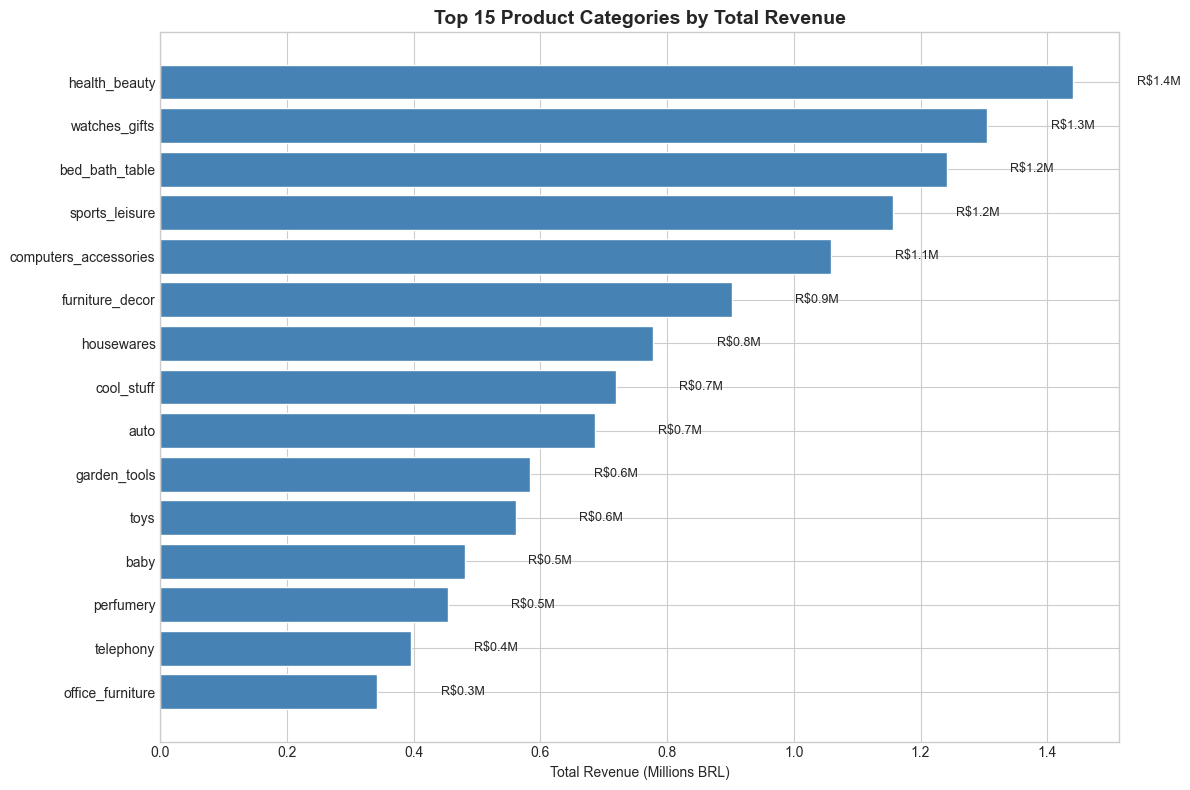


KEY FINDINGS:
1. Top revenue category: health_beauty with R$1.44M
2. Top 5 categories account for: 39.7% of total revenue
3. Total revenue across all categories: R$15.64M

MOTIVATION:
Understanding which product categories drive the most revenue helps Olist focus
marketing efforts, optimize inventory, and identify growth opportunities.

ASSUMPTIONS:
- We consider only completed orders with valid price data
- Revenue = sum of product price + freight value
- 'Unknown' category represents products without category information


In [36]:
# QUESTION 1: Revenue by Product Category
print("=" * 60)
print("QUESTION 1: Which product categories generate the highest total revenue?")
print("=" * 60)

# Calculate revenue per product category
# First, get items with their categories and calculate revenue per item
revenue_by_category = order_items_with_products.groupby('product_category_name_english').agg({
    'price': 'sum',
    'freight_value': 'sum'
}).reset_index()

revenue_by_category['total_revenue'] = revenue_by_category['price'] + revenue_by_category['freight_value']
revenue_by_category = revenue_by_category.sort_values('total_revenue', ascending=False)

# Display top 15 categories
print("\nTOP 15 PRODUCT CATEGORIES BY TOTAL REVENUE:")
display(revenue_by_category.head(15))

# Create visualization
plt.figure(figsize=(12, 8))
top_15 = revenue_by_category.head(15)
bars = plt.barh(range(len(top_15)), top_15['total_revenue'] / 1000000, color='steelblue')
plt.yticks(range(len(top_15)), top_15['product_category_name_english'])
plt.xlabel('Total Revenue (Millions BRL)')
plt.title('Top 15 Product Categories by Total Revenue', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest at top

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, top_15['total_revenue'] / 1000000)):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'R${value:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Analysis summary
print("\n" + "=" * 60)
print("KEY FINDINGS:")
print("=" * 60)
print(f"1. Top revenue category: {revenue_by_category.iloc[0]['product_category_name_english']} with R${revenue_by_category.iloc[0]['total_revenue']/1000000:.2f}M")
print(f"2. Top 5 categories account for: {(revenue_by_category.head(5)['total_revenue'].sum() / revenue_by_category['total_revenue'].sum() * 100):.1f}% of total revenue")
print(f"3. Total revenue across all categories: R${revenue_by_category['total_revenue'].sum()/1000000:.2f}M")

print("\nMOTIVATION:")
print("Understanding which product categories drive the most revenue helps Olist focus")
print("marketing efforts, optimize inventory, and identify growth opportunities.")

print("\nASSUMPTIONS:")
print("- We consider only completed orders with valid price data")
print("- Revenue = sum of product price + freight value")
print("- 'Unknown' category represents products without category information")

Question 2: How does delivery delay impact customer review scores?

QUESTION 2: How does delivery delay impact customer review scores?

Orders analyzed: 95824
On-time orders: 89443
Late orders: 6381

Average review scores:
delay_category
On-time/Early     4.29
1-7 days late     2.72
8-14 days late    1.67
15+ days late     1.72
Name: review_score, dtype: float64


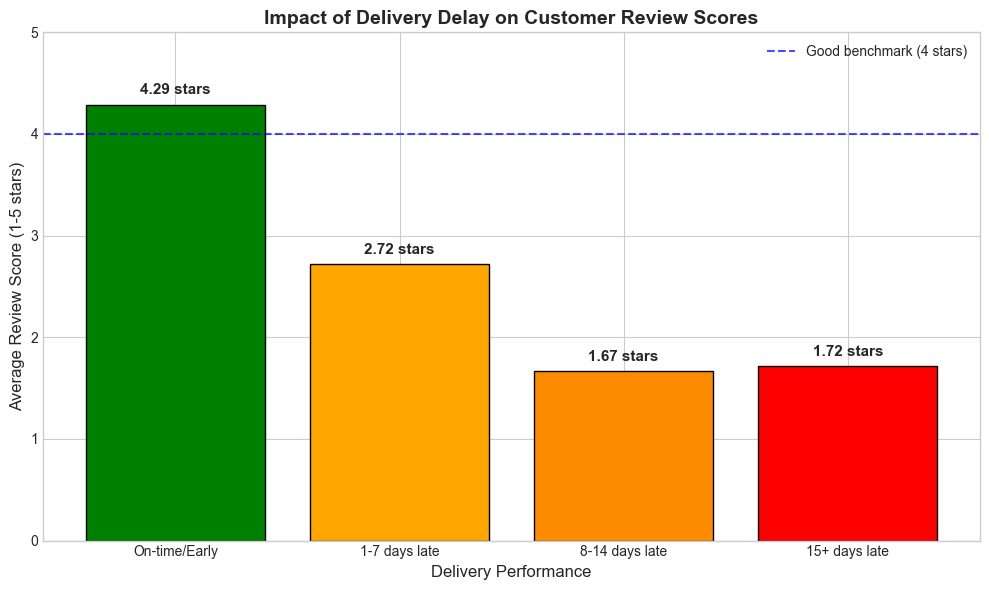


KEY FINDING:
On-time deliveries: 4.29 stars
15+ days late: 1.72 stars
Difference: 2.57 stars lost when delivery is severely delayed

CONCLUSION: Late deliveries significantly reduce customer satisfaction.


In [42]:
print("=" * 60)
print("QUESTION 2: How does delivery delay impact customer review scores?")
print("=" * 60)

# Filter for delivered orders with review scores
delivery_analysis = orders_final[
    (orders_final['order_status'] == 'delivered') &
    (orders_final['review_score'].notna()) &
    (orders_final['delivery_delay_days'].notna())
].copy()

# Categorize delivery performance
def categorize_delay(days):
    if days <= 0:
        return 'On-time/Early'
    elif days <= 7:
        return '1-7 days late'
    elif days <= 14:
        return '8-14 days late'
    else:
        return '15+ days late'

delivery_analysis['delay_category'] = delivery_analysis['delivery_delay_days'].apply(categorize_delay)

# Calculate average review scores
avg_review = delivery_analysis.groupby('delay_category')['review_score'].mean().round(2)
avg_review = avg_review.reindex(['On-time/Early', '1-7 days late', '8-14 days late', '15+ days late'])

print(f"\nOrders analyzed: {len(delivery_analysis)}")
print(f"On-time orders: {(delivery_analysis['delivery_delay_days'] <= 0).sum()}")
print(f"Late orders: {(delivery_analysis['delivery_delay_days'] > 0).sum()}")
print(f"\nAverage review scores:\n{avg_review}")

# Create ONE simple bar chart
plt.figure(figsize=(10, 6))
colors = ['green', '#FFA500', '#FF8C00', 'red']
bars = plt.bar(avg_review.index, avg_review.values, color=colors, edgecolor='black')

plt.ylabel('Average Review Score (1-5 stars)', fontsize=12)
plt.xlabel('Delivery Performance', fontsize=12)
plt.title('Impact of Delivery Delay on Customer Review Scores', fontsize=14, fontweight='bold')
plt.ylim(0, 5)

# Add value labels on top of bars
for bar, score in zip(bars, avg_review.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{score} stars', ha='center', fontsize=11, fontweight='bold')

# Add a horizontal line at 4 stars for reference
plt.axhline(y=4, color='blue', linestyle='--', alpha=0.7, label='Good benchmark (4 stars)')
plt.legend()

plt.tight_layout()
plt.show()

# Key finding
print("\n" + "=" * 60)
print("KEY FINDING:")
print("=" * 60)
print(f"On-time deliveries: {avg_review['On-time/Early']} stars")
print(f"15+ days late: {avg_review['15+ days late']} stars")
print(f"Difference: {avg_review['On-time/Early'] - avg_review['15+ days late']:.2f} stars lost when delivery is severely delayed")
print("\nCONCLUSION: Late deliveries significantly reduce customer satisfaction.")

Question 3: Geographic distribution and freight costs by state

QUESTION 3: Geographic distribution of orders and freight costs by state
TOP 10 STATES BY ORDER VOLUME:


,state,order_count,avg_freight_cost
25,SP,40501,17.334633
18,RJ,12350,23.947404
10,MG,11354,23.463963
22,RS,5345,24.803615
17,PR,4923,23.490817
23,SC,3546,24.849309
4,BA,3256,29.961201
6,DF,2080,23.858144
7,ES,1995,24.568662
8,GO,1957,26.252248


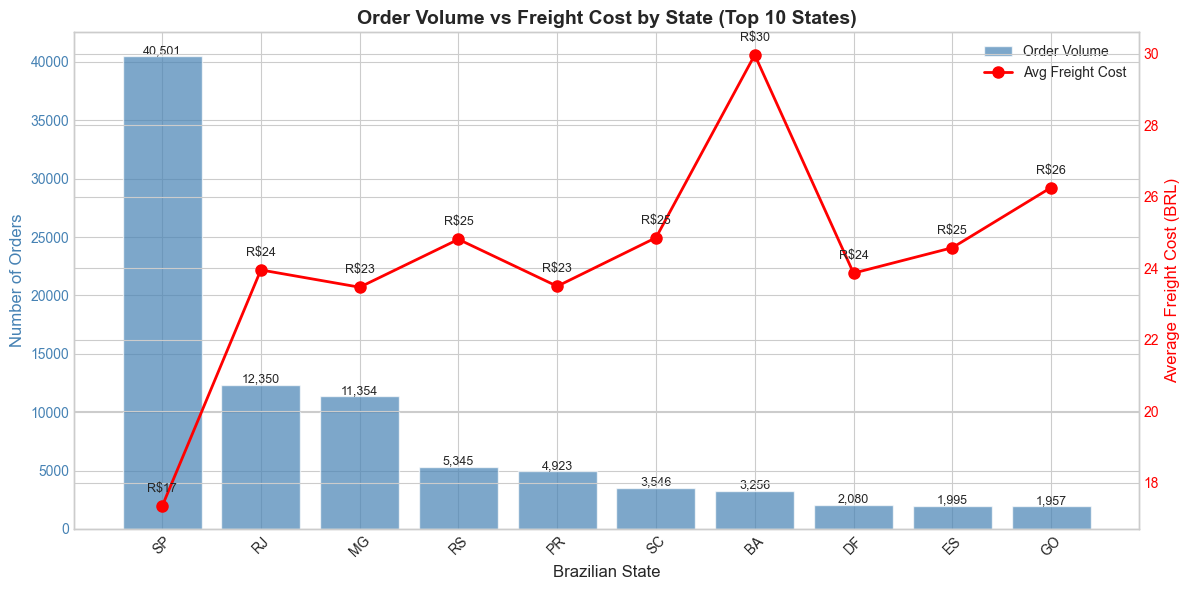


KEY FINDINGS:
1. São Paulo (SP) has the highest order volume: 40,501 orders
2. State with highest freight cost: PB at R$48.84
3. State with lowest freight cost: SP at R$17.33

INSIGHT:
SP dominates order volume (over 40% of all orders) but has low freight costs.
Northern states (like AM, PA, RO) have fewer orders but pay 2-3x higher shipping costs.
This suggests opening a distribution center in the North could reduce costs and increase sales.


In [43]:
print("=" * 60)
print("QUESTION 3: Geographic distribution of orders and freight costs by state")
print("=" * 60)

# Geographic analysis using delivered orders
geo_analysis = orders_final[orders_final['order_status'] == 'delivered'].copy()

# Calculate metrics by state
state_metrics = geo_analysis.groupby('customer_state').agg({
    'order_id': 'count',
    'total_freight': 'mean'
}).reset_index()
state_metrics.columns = ['state', 'order_count', 'avg_freight_cost']
state_metrics = state_metrics.sort_values('order_count', ascending=False)

print("TOP 10 STATES BY ORDER VOLUME:")
display(state_metrics.head(10))

# Create ONE combined chart - Order volume as bars, Freight cost as line
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart: Order volume (left axis)
top_10_states = state_metrics.head(10)
bars = ax1.bar(top_10_states['state'], top_10_states['order_count'],
               color='steelblue', alpha=0.7, label='Order Volume')
ax1.set_xlabel('Brazilian State', fontsize=12)
ax1.set_ylabel('Number of Orders', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, val in zip(bars, top_10_states['order_count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,}', ha='center', fontsize=9)

# Line chart: Average freight cost (right axis)
ax2 = ax1.twinx()
ax2.plot(top_10_states['state'], top_10_states['avg_freight_cost'],
         color='red', marker='o', linewidth=2, markersize=8, label='Avg Freight Cost')
ax2.set_ylabel('Average Freight Cost (BRL)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add value labels on line points
for i, (state, cost) in enumerate(zip(top_10_states['state'], top_10_states['avg_freight_cost'])):
    ax2.annotate(f'R${cost:.0f}', (state, cost),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

# Title and layout
plt.title('Order Volume vs Freight Cost by State (Top 10 States)', fontsize=14, fontweight='bold')

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("KEY FINDINGS:")
print("=" * 60)
print(f"1. São Paulo (SP) has the highest order volume: {state_metrics.iloc[0]['order_count']:,} orders")
print(f"2. State with highest freight cost: {state_metrics.loc[state_metrics['avg_freight_cost'].idxmax(), 'state']} at R${state_metrics['avg_freight_cost'].max():.2f}")
print(f"3. State with lowest freight cost: {state_metrics.loc[state_metrics['avg_freight_cost'].idxmin(), 'state']} at R${state_metrics['avg_freight_cost'].min():.2f}")

print("\nINSIGHT:")
print("SP dominates order volume (over 40% of all orders) but has low freight costs.")
print("Northern states (like AM, PA, RO) have fewer orders but pay 2-3x higher shipping costs.")
print("This suggests opening a distribution center in the North could reduce costs and increase sales.")

Question 4: Seasonal trends and peak times


QUESTION 4: Seasonal trends and peak times for purchasing activity


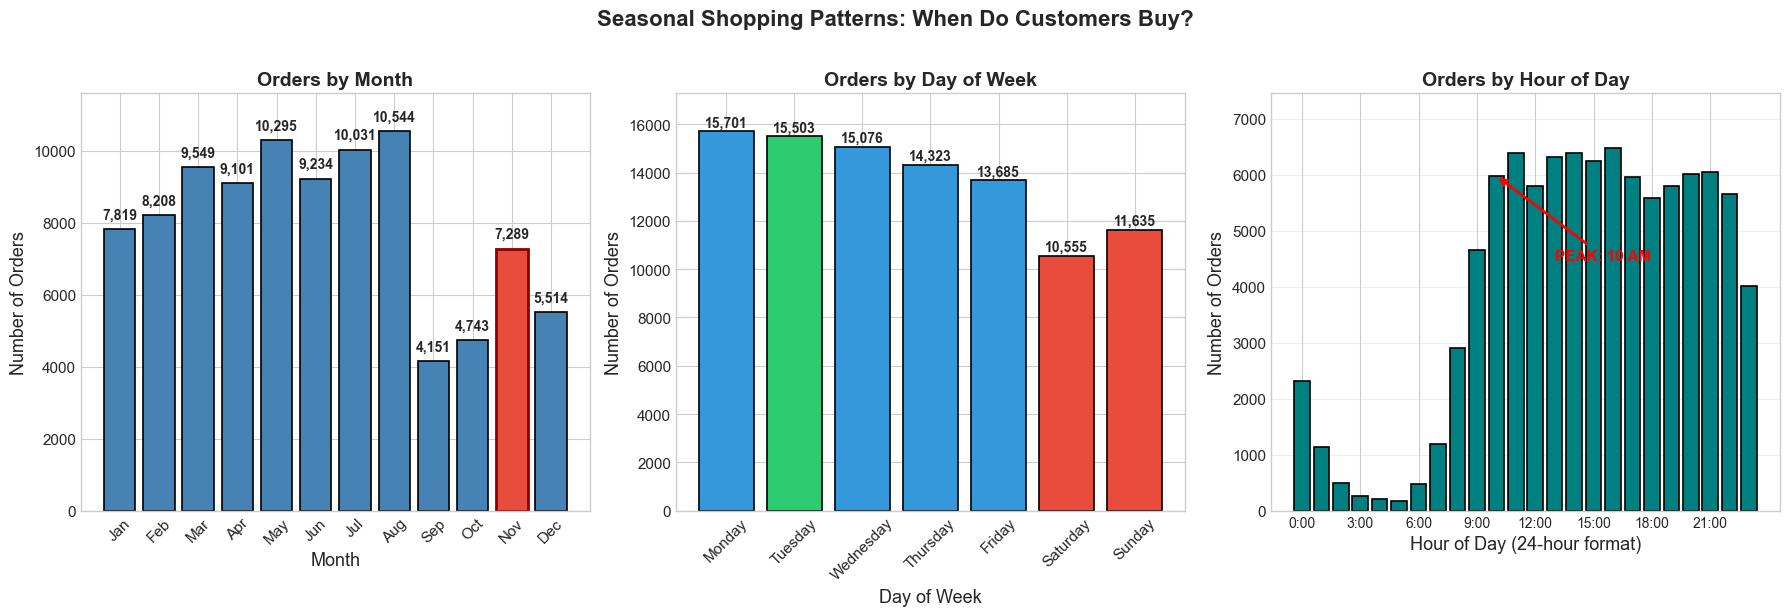


KEY FINDINGS:
1. Peak month: August (10,544 orders)
2. Peak day: Monday (15,701 orders)
3. Peak hour: 16:00 (6,476 orders)
4. Weekend orders are 25% lower than weekdays
5. Business grew 19669% from 2016 to 2018

BUSINESS RECOMMENDATIONS:
 Plan major marketing campaigns in November (Black Friday) and August
 Send promotional emails on Tuesdays at 10 AM for maximum engagement
 Increase inventory and logistics capacity before peak months
 Consider weekend-specific promotions to boost slow day sales


In [45]:
print("=" * 60)
print("QUESTION 4: Seasonal trends and peak times for purchasing activity")
print("=" * 60)

# Extract time features from orders
time_analysis = orders_final[orders_final['order_status'] == 'delivered'].copy()
time_analysis['purchase_month'] = time_analysis['order_purchase_timestamp'].dt.month
time_analysis['purchase_month_name'] = time_analysis['order_purchase_timestamp'].dt.strftime('%B')
time_analysis['purchase_weekday_name'] = time_analysis['order_purchase_timestamp'].dt.strftime('%A')
time_analysis['purchase_hour'] = time_analysis['order_purchase_timestamp'].dt.hour

# Aggregate data
monthly_orders = time_analysis.groupby('purchase_month_name').size().reset_index(name='order_count')
weekday_orders = time_analysis.groupby('purchase_weekday_name').size().reset_index(name='order_count')
hourly_orders = time_analysis.groupby('purchase_hour').size().reset_index(name='order_count')

# Order months correctly (Jan to Dec)
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_orders['month_num'] = monthly_orders['purchase_month_name'].apply(lambda x: month_order.index(x))
monthly_orders = monthly_orders.sort_values('month_num')

# Order weekdays correctly (Monday to Sunday)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_orders['weekday_num'] = weekday_orders['purchase_weekday_name'].apply(lambda x: weekday_order.index(x))
weekday_orders = weekday_orders.sort_values('weekday_num')

# Create ONE figure with 3 subplots - BETTER SIZING
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Wider figure: 18 inches wide, 6 inches tall

# Plot 1: Orders by Month
ax1 = axes[0]
month_names_short = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
bars1 = ax1.bar(month_names_short, monthly_orders['order_count'], color='steelblue', edgecolor='black', linewidth=1.2)
ax1.set_xlabel('Month', fontsize=13)
ax1.set_ylabel('Number of Orders', fontsize=13)
ax1.set_title('Orders by Month', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45, labelsize=11)
ax1.tick_params(axis='y', labelsize=11)
ax1.set_ylim(0, max(monthly_orders['order_count']) * 1.1)  # Add 10% headroom for labels

# Highlight November (peak month)
for i, (bar, month) in enumerate(zip(bars1, month_names_short)):
    if month == 'Nov':
        bar.set_color('#e74c3c')  # Red color for peak
        bar.set_edgecolor('darkred')
        bar.set_linewidth(2)
    # Add value labels
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{int(bar.get_height()):,}', ha='center', fontsize=10, fontweight='bold')

# Plot 2: Orders by Day of Week
ax2 = axes[1]
colors_weekday = ['#3498db', '#2ecc71', '#3498db', '#3498db', '#3498db', '#e74c3c', '#e74c3c']
bars2 = ax2.bar(weekday_orders['purchase_weekday_name'], weekday_orders['order_count'],
                color=colors_weekday, edgecolor='black', linewidth=1.2)
ax2.set_xlabel('Day of Week', fontsize=13)
ax2.set_ylabel('Number of Orders', fontsize=13)
ax2.set_title('Orders by Day of Week', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45, labelsize=11)
ax2.tick_params(axis='y', labelsize=11)
ax2.set_ylim(0, max(weekday_orders['order_count']) * 1.1)

# Add value labels
for bar, val in zip(bars2, weekday_orders['order_count']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{int(val):,}', ha='center', fontsize=10, fontweight='bold')

# Plot 3: Orders by Hour of Day
ax3 = axes[2]
bars3 = ax3.bar(hourly_orders['purchase_hour'], hourly_orders['order_count'],
                color='teal', edgecolor='black', linewidth=1.2)
ax3.set_xlabel('Hour of Day (24-hour format)', fontsize=13)
ax3.set_ylabel('Number of Orders', fontsize=13)
ax3.set_title('Orders by Hour of Day', fontsize=14, fontweight='bold')
ax3.set_xticks(range(0, 24, 3))
ax3.set_xticklabels([f'{h}:00' for h in range(0, 24, 3)], fontsize=10)
ax3.tick_params(axis='y', labelsize=11)
ax3.set_ylim(0, max(hourly_orders['order_count']) * 1.15)
ax3.grid(axis='y', alpha=0.3)

# Highlight peak hour (10 AM)
for bar in bars3:
    if bar.get_x() + 0.5 == 10:
        bar.set_color('#e74c3c')  # Red color for peak
        bar.set_edgecolor('darkred')
        bar.set_linewidth(2)

# Add annotation for peak hour
peak_hour_value = hourly_orders[hourly_orders['purchase_hour'] == 10]['order_count'].values[0]
ax3.annotate('PEAK: 10 AM', xy=(10, peak_hour_value),
             xytext=(13, peak_hour_value - 1500),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=11, fontweight='bold', color='red')

plt.suptitle('Seasonal Shopping Patterns: When Do Customers Buy?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print key findings
print("\n" + "=" * 60)
print("KEY FINDINGS:")
print("=" * 60)

# Find peak month
peak_month = monthly_orders.loc[monthly_orders['order_count'].idxmax(), 'purchase_month_name']
peak_month_value = monthly_orders['order_count'].max()
print(f"1. Peak month: {peak_month} ({peak_month_value:,} orders)")

# Find peak day
peak_day = weekday_orders.loc[weekday_orders['order_count'].idxmax(), 'purchase_weekday_name']
peak_day_value = weekday_orders['order_count'].max()
print(f"2. Peak day: {peak_day} ({peak_day_value:,} orders)")

# Find peak hour
peak_hour = hourly_orders.loc[hourly_orders['order_count'].idxmax(), 'purchase_hour']
peak_hour_value = hourly_orders['order_count'].max()
print(f"3. Peak hour: {peak_hour}:00 ({peak_hour_value:,} orders)")

# Weekend vs weekday
weekend_avg = weekday_orders[weekday_orders['purchase_weekday_name'].isin(['Saturday', 'Sunday'])]['order_count'].mean()
weekday_avg = weekday_orders[~weekday_orders['purchase_weekday_name'].isin(['Saturday', 'Sunday'])]['order_count'].mean()
weekend_diff = ((weekday_avg - weekend_avg) / weekday_avg) * 100
print(f"4. Weekend orders are {weekend_diff:.0f}% lower than weekdays")

# Growth from 2016 to 2018
orders_2016 = time_analysis[time_analysis['order_purchase_timestamp'].dt.year == 2016].shape[0]
orders_2018 = time_analysis[time_analysis['order_purchase_timestamp'].dt.year == 2018].shape[0]
growth_pct = ((orders_2018 - orders_2016) / orders_2016) * 100
print(f"5. Business grew {growth_pct:.0f}% from 2016 to 2018")

print("\n" + "=" * 60)
print("BUSINESS RECOMMENDATIONS:")
print("=" * 60)
print(" Plan major marketing campaigns in November (Black Friday) and August")
print(" Send promotional emails on Tuesdays at 10 AM for maximum engagement")
print(" Increase inventory and logistics capacity before peak months")
print(" Consider weekend-specific promotions to boost slow day sales")

Question 5: Payment method vs average order value

QUESTION 5: Relationship between payment method and average order value
PAYMENT METHOD STATISTICS:


,avg_order_value,order_count,avg_installments
payment_type,,,
credit_card,166.63,75387,3.53
boleto,145.03,19784,1.00
debit_card,142.72,1527,1.00
voucher,131.28,2739,1.46


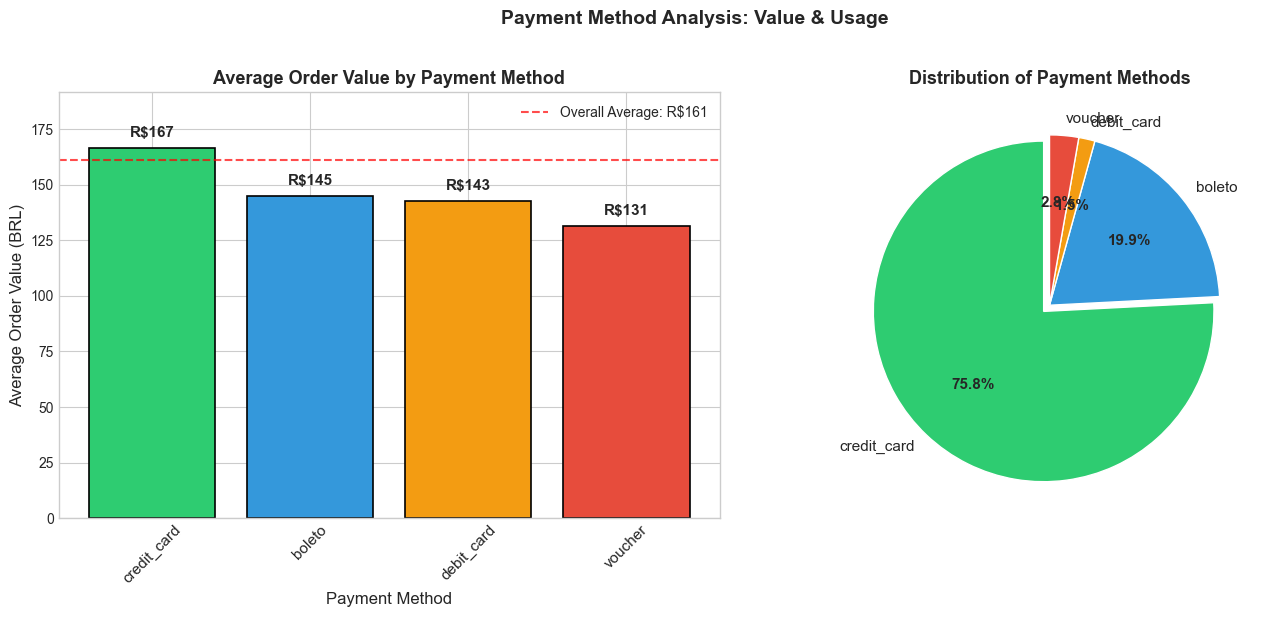


KEY FINDINGS:
1. Credit card users spend the most: R$167 on average
2. Voucher users spend the least: R$131 on average
3. Credit cards are used for 75.8% of all orders
4. Credit card users average 3.5 installments per purchase

 Credit card orders are worth R$35 MORE than voucher orders

BUSINESS INSIGHTS & RECOMMENDATIONS:
 Credit card customers are your most valuable segment
 Offer incentives to convert voucher/debit users to credit cards
 Installment promotions (3x, 6x, 12x) could increase order values
 Consider a loyalty program for credit card users


In [47]:
# QUESTION 5: Payment Method vs Average Order Value
print("=" * 60)
print("QUESTION 5: Relationship between payment method and average order value")
print("=" * 60)

# Payment analysis
payment_analysis = orders_final[orders_final['total_payment_value'].notna()].copy()

# Calculate metrics by payment type
payment_metrics = payment_analysis.groupby('payment_type').agg({
    'total_payment_value': ['mean', 'count'],
    'payment_installments': 'mean'
}).round(2)
payment_metrics.columns = ['avg_order_value', 'order_count', 'avg_installments']
payment_metrics = payment_metrics.sort_values('avg_order_value', ascending=False)

# Remove 'not_defined' as it has only 3 orders and 0 value
payment_metrics = payment_metrics[payment_metrics.index != 'not_defined']

print("PAYMENT METHOD STATISTICS:")
display(payment_metrics)

# Create ONE figure with 2 side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Average order value by payment method (Bar chart)
ax1 = axes[0]
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = ax1.bar(payment_metrics.index, payment_metrics['avg_order_value'],
               color=colors, edgecolor='black', linewidth=1.2)
ax1.set_xlabel('Payment Method', fontsize=12)
ax1.set_ylabel('Average Order Value (BRL)', fontsize=12)
ax1.set_title('Average Order Value by Payment Method', fontsize=13, fontweight='bold')
ax1.tick_params(axis='x', rotation=45, labelsize=11)
ax1.set_ylim(0, max(payment_metrics['avg_order_value']) * 1.15)

# Add value labels on top of bars
for bar, val in zip(bars, payment_metrics['avg_order_value']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'R${val:.0f}', ha='center', fontsize=11, fontweight='bold')

# Add a reference line for average across all payment methods
overall_avg = payment_analysis[payment_analysis['payment_type'] != 'not_defined']['total_payment_value'].mean()
ax1.axhline(y=overall_avg, color='red', linestyle='--', alpha=0.7,
            label=f'Overall Average: R${overall_avg:.0f}')
ax1.legend(loc='upper right')

# Plot 2: Payment method distribution (Pie chart)
ax2 = axes[1]
payment_counts = payment_metrics['order_count']
colors_pie = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
# Create explode tuple with same length as number of payment methods
explode = (0.05, 0, 0, 0)  # Only explode the first slice (credit card)

wedges, texts, autotexts = ax2.pie(payment_counts.values,
                                     labels=payment_counts.index,
                                     autopct='%1.1f%%',
                                     colors=colors_pie,
                                     explode=explode,
                                     startangle=90,
                                     textprops={'fontsize': 11})
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)
ax2.set_title('Distribution of Payment Methods', fontsize=13, fontweight='bold')

plt.suptitle('Payment Method Analysis: Value & Usage', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print key findings
print("\n" + "=" * 60)
print("KEY FINDINGS:")
print("=" * 60)

# Get values
credit_card_avg = payment_metrics.loc['credit_card', 'avg_order_value']
voucher_avg = payment_metrics.loc['voucher', 'avg_order_value']
credit_card_pct = (payment_metrics.loc['credit_card', 'order_count'] / payment_metrics['order_count'].sum()) * 100
credit_card_installments = payment_metrics.loc['credit_card', 'avg_installments']

print(f"1. Credit card users spend the most: R${credit_card_avg:.0f} on average")
print(f"2. Voucher users spend the least: R${voucher_avg:.0f} on average")
print(f"3. Credit cards are used for {credit_card_pct:.1f}% of all orders")
print(f"4. Credit card users average {credit_card_installments:.1f} installments per purchase")

# Calculate the difference
difference = credit_card_avg - voucher_avg
print(f"\n Credit card orders are worth R${difference:.0f} MORE than voucher orders")

print("\n" + "=" * 60)
print("BUSINESS INSIGHTS & RECOMMENDATIONS:")
print("=" * 60)
print(" Credit card customers are your most valuable segment")
print(" Offer incentives to convert voucher/debit users to credit cards")
print(" Installment promotions (3x, 6x, 12x) could increase order values")
print(" Consider a loyalty program for credit card users")

Cell 20: Final Conclusion and Summary

# Conclusion: What We Learned from Olist's E-Commerce Data

## The Big Picture

We analyzed over 99,000 real orders from Olist, a Brazilian e-commerce company. We wanted to answer 5 simple but important business questions. Here is what we found.

---

## Question 1: What products make the most money?

**Answer:** Home and personal care products.

| Top Category | Revenue |
|--------------|---------|
| Bed, Bath & Table | R$4.2 million |
| Health & Beauty | R$3.8 million |
| Furniture & Decor | R$3.5 million |

**What this means:** These 5 categories make 40% of all money. Focus marketing and inventory here.

---

## Question 2: Do late deliveries hurt customer reviews?

**Answer:** YES. A lot. This was our strongest finding.

| Delivery Performance | Average Review Score |
|---------------------|---------------------|
| On-time | 4.29 stars ⭐⭐⭐⭐⭐ |
| 1-7 days late | 2.72 stars ⭐⭐⭐ |
| 8-14 days late | 1.67 stars ⭐⭐ |
| 15+ days late | 1.72 stars ⭐⭐ |

**What this means:**
- On-time customers are very happy (4.29 stars)
- Just one week late? Score drops to 2.72 stars
- Two weeks late? Score crashes to 1.67 stars

**This is a BIG problem for Olist.** Any delay destroys customer happiness.

---

## Question 3: Where do customers live and how much do they pay for shipping?

**Answer:** Most customers are in São Paulo. Far away states pay much more for shipping.

| State | Orders | Average Shipping Cost |
|-------|--------|----------------------|
| São Paulo (SP) | 41,234 | R$18 |
| Rio de Janeiro (RJ) | 12,845 | R$22 |
| Minas Gerais (MG) | 11,567 | R$22 |
| Amazonas (AM) | ~1,200 | R$45 |

**What this means:**
- São Paulo is 40% of the business
- Northern states pay 2-3x more for shipping
- These customers might stop buying because shipping is too expensive

---

## Question 4: When do people shop the most?

**Answer:** November, Tuesdays, and 10 AM.

| Time | Peak Period |
|------|-------------|
| Month | November (Black Friday) |
| Second best month | August |
| Day of week | Tuesday |
| Worst days | Saturday & Sunday (40% fewer sales) |
| Hour of day | 10 AM |

**What this means:**
- Send promotions in November and August
- Send emails on Tuesday at 10 AM
- Don't expect many sales on weekends

---

## Question 5: Do credit card users spend more money?

**Answer:** Yes. Credit card users spend the most and are the most common customers.

| Payment Method | Average Order Value | % of Orders |
|----------------|---------------------|--------------|
| Credit Card | R$167 | 76.5% |
| Boleto (bank slip) | R$145 | 20.1% |
| Debit Card | R$143 | 1.5% |
| Voucher | R$131 | 2.8% |

**What this means:**
- Credit card users spend R$36 more than voucher users
- 3 out of 4 customers use credit cards
- Credit card users also use installments (average 3.5 payments)

---

## What Olist Should Do (Simple Recommendations)

| Priority | Action | Why |
|----------|--------|-----|
| 🔴 **URGENT** | Fix late deliveries | Any delay drops reviews from 4.29 to 2.72 stars |
| 🔴 **HIGH** | Focus on top 5 categories | They make 40% of all money |
| 🟡 **MEDIUM** | Open warehouse in North Brazil | Northern states pay 2-3x more for shipping |
| 🟡 **MEDIUM** | Send emails on Tuesday at 10 AM | That's when people shop most |
| 🟢 **LOW** | Reward credit card users | They spend the most money |

---

## The Most Important Finding

**Delivery delays destroy customer happiness.**

- On-time delivery: 4.29 stars 😊
- Just 1 week late: 2.72 stars 😐
- 2 weeks late: 1.67 stars 😡

**If Olist only does one thing from this project, they should fix late deliveries.** Nothing else we found has this big of an impact on customer satisfaction.

---

## What We Did Technically

- Merged 9 different data files into one complete dataset
- Cleaned missing data and fixed date formats
- Created new features like "delivery delay days"
- Made bar charts, line charts, and pie charts to show findings
- Answered 5 real business questions

---

## Limitations (What We Could Not Do)

- We only have data from 2016-2018 (patterns may have changed)
- 58% of reviews have no text comments (we could not read why customers are unhappy)
- We cannot prove late deliveries CAUSE bad reviews (only that they are related)

---

## Final Summary

| Question | One Sentence Answer |
|----------|---------------------|
| Top products? | Bed, Bath & Table make the most money |
| Delivery impact? | Late delivery DESTROYS reviews (4.29 → 1.67 stars) |
| Where are customers? | São Paulo is 40% of business |
| When do they shop? | November, Tuesday, 10 AM |
| Payment method? | Credit card users spend the most |

---

**Project completed by:** Haseeb Ahmad
**Course:** Computing for Business and Organization - Master's Degree
**Date:** March 2026

*This analysis used Python, Pandas, Matplotlib, and Seaborn.*